# Solutions · 16 · Fourier analysis: diagnosing a machine from its vibration

Worked solutions to the exercises of [notebook 16](../notebooks/16_fourier_analysis.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import datasets, fourier
data = np.loadtxt(datasets.path("pump_vibration.csv"), delimiter=",", skiprows=1)
t, signal = data[:, 0], data[:, 1]
fs = 1/(t[1] - t[0])
f_shaft = 1480/60

## Exercise 1

Use only the first 0.25 s of data. Can you still separate the shaft peak from its second harmonic?
   What is the frequency resolution now?

record 0.25 s: frequency resolution 4.0 Hz
  near  24.67 Hz: amplitude 0.962 mm/s
  near  49.33 Hz: amplitude 0.370 mm/s
  near 137.30 Hz: amplitude 0.189 mm/s
  median amplitude 60-250 Hz (noise level): 0.042 mm/s


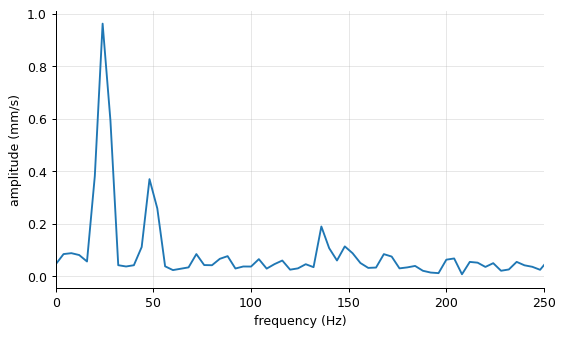

In [2]:
short = signal[: int(0.25*fs)]
f, a = fourier.spectrum(short, fs)
print(f"record 0.25 s: frequency resolution {fs/short.size:.1f} Hz")
for target in (f_shaft, 2*f_shaft, 137.3):
    i = np.argmin(abs(f - target))
    print(f"  near {target:6.2f} Hz: amplitude {a[i]:.3f} mm/s")
print(f"  median amplitude 60-250 Hz (noise level): {np.median(a[(f > 60) & (f < 250)]):.3f} mm/s")
plt.plot(f, a); plt.xlim(0, 250); plt.xlabel("frequency (Hz)"); plt.ylabel("amplitude (mm/s)"); plt.show()

The resolution is now 4 Hz. The shaft peak (24.7 Hz) and its harmonic (49.3 Hz) are about 25 Hz apart, so
they remain clearly separated. What suffers is the weak defect component: with a shorter record the
noise level in the spectrum rises (0.042 mm/s instead of 0.018 mm/s with the full 2 s), so the defect
peak stands out only about 4.5 times above the noise instead of 8 times - and its height is less
accurate. Longer records improve both resolution and sensitivity.

## Exercise 2

Zero-pad the 0.25 s record to 2 s (append zeros) and recompute the spectrum. Does that improve the
   *resolution*, or only make the curve smoother?

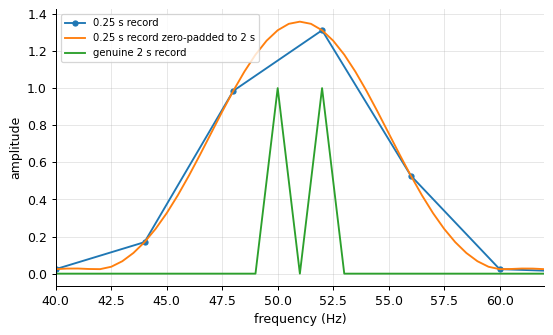

In [3]:
fs_t = 1000.0
def amp_spectrum(x, n_fft):
    # Hann window over the RECORDED samples, then zero-pad to n_fft points
    w = 0.5 - 0.5*np.cos(2*np.pi*np.arange(x.size)/x.size)
    X = np.fft.rfft(x*w, n=n_fft)
    return np.fft.rfftfreq(n_fft, 1/fs_t), 2*np.abs(X)/w.sum()
two_tones = lambda T: np.sin(2*np.pi*50*np.arange(int(T*fs_t))/fs_t) + np.sin(2*np.pi*52*np.arange(int(T*fs_t))/fs_t)
f1, a1 = amp_spectrum(two_tones(0.25), 250)          # 0.25 s record as it is
f2, a2 = amp_spectrum(two_tones(0.25), 2000)         # same record, zero-padded to 2 s
f3, a3 = amp_spectrum(two_tones(2.0), 2000)          # a genuine 2 s record
plt.plot(f1, a1, "o-", ms=4, label="0.25 s record")
plt.plot(f2, a2, label="0.25 s record zero-padded to 2 s")
plt.plot(f3, a3, label="genuine 2 s record")
plt.xlim(40, 62); plt.xlabel("frequency (Hz)"); plt.ylabel("amplitude"); plt.legend(fontsize=8); plt.show()

Zero-padding interpolates the same spectrum on a finer frequency grid: the curve becomes smooth, but the
two tones 2 Hz apart still appear as a **single** broad peak, because the 0.25 s record contains no
information to separate them. Only the genuinely longer record resolves them. (Apply the window to the
recorded samples *before* padding - windowing the padded array would suppress the data themselves.)
Resolution comes from measurement time, not from computation.

## Exercise 3

By Parseval's theorem the mean square of the signal equals the sum of squared Fourier amplitudes
   (suitably scaled). Compute the RMS vibration velocity from the spectrum and compare with
   `np.sqrt(np.mean(signal**2))` - the quantity used in vibration-severity standards.

In [4]:
N = signal.size
X = np.fft.rfft(signal)
mean_square = (np.abs(X[0])**2 + 2*np.sum(np.abs(X[1:-1])**2) + np.abs(X[-1])**2) / N**2
print(f"RMS from the spectrum (Parseval): {np.sqrt(mean_square):.4f} mm/s")
print(f"RMS in the time domain:           {np.sqrt(np.mean(signal**2)):.4f} mm/s")
print(f"sine components only: sqrt(sum A²/2) = {np.sqrt((1.0**2 + 0.4**2 + 0.15**2)/2):.4f} mm/s; noise alone 0.5 mm/s")

RMS from the spectrum (Parseval): 0.9148 mm/s
RMS in the time domain:           0.9148 mm/s
sine components only: sqrt(sum A²/2) = 0.7689 mm/s; noise alone 0.5 mm/s


Parseval's theorem: the energy (mean square) is the same in time and in frequency. The overall RMS
combines the sinusoids ($A^2/2$ each) and the noise variance ($0.5^2$). Vibration-severity standards
(e.g. ISO 10816/20816) grade machines by this broadband RMS velocity - but, as here, a harmful defect can
hide under a healthy-looking RMS value. The spectrum shows *what* vibrates.

## Exercise 4

**Implement it yourself:** compute the frequency response of a 5-point moving average (notebook 07) by taking the FFT of its kernel zero-padded to 1024 points. Which frequencies does it suppress, and why is it a poor low-pass filter?

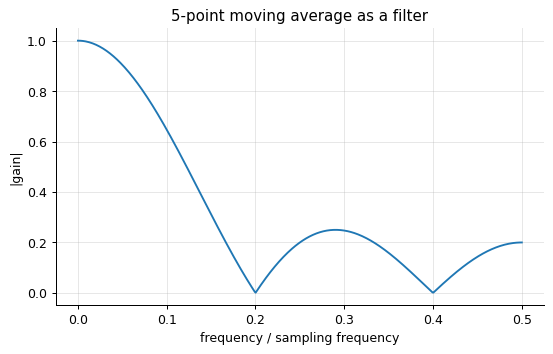

zeros of the response near [0.201 0.401] fs (theory: 0.2 and 0.4); largest sidelobe gain 0.25


In [5]:
kernel = np.zeros(1024); kernel[:5] = 1/5
H = np.abs(np.fft.rfft(kernel))
f_norm = np.fft.rfftfreq(1024)                        # in units of the sampling frequency
plt.plot(f_norm, H); plt.xlabel("frequency / sampling frequency"); plt.ylabel("|gain|")
plt.title("5-point moving average as a filter"); plt.show()
zeros = f_norm[1:][np.where((H[1:-1] < H[:-2]) & (H[1:-1] < H[2:]))[0] + 1][:2]
side = H[(f_norm > 0.2) & (f_norm < 0.4)].max()
print(f"zeros of the response near {np.round(zeros, 3)} fs (theory: 0.2 and 0.4); largest sidelobe gain {side:.2f}")

The moving average suppresses frequencies that fit a whole number of cycles into its 5-point window
(0.2 and 0.4 of the sampling frequency), but between those zeros high frequencies pass with gains up to
about 0.25 (the sidelobes), and the pass band droops gradually. A good low-pass filter should pass low
frequencies flat and block high ones strongly - the moving average does neither well, which is why
Savitzky-Golay or properly designed filters are preferred.